# 05 — Baseline de modelado

Baseline para predecir `rhythm_label` a partir de las features generadas en `04_windowing_and_feature_engineering.ipynb`.

**Alcance de este notebook**

- Validar mecánica del pipeline: `SimpleImputer → StandardScaler → Clasificador`.
- Split estricto por `case_id` (`GroupKFold` / `GroupShuffleSplit`).
- Manejo de desbalance vía `class_weight="balanced"`.
- Reportar métricas macro, reporte por clase con soporte y matriz de confusión en conteos absolutos con totales por fila y columna.

**Restricciones obligatorias**

- `beat_type` **NO** se usa como predictor (lo verifica `assert_no_forbidden_features`).
- Split por `case_id`, nunca por ventana ni latido aleatorio.
- No reportar cifras antes de ejecutar las celdas con datos reales.

**Pre-requisito**

Haber ejecutado:
1. `03_ecg_loading_and_visualization.ipynb` para descargar los ECG de todos los `case_id` que se quieran usar.
2. `04_windowing_and_feature_engineering.ipynb` para generar `data/processed/features_baseline.parquet` con esos casos.

## 1. Setup

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.modeling import (
    assert_no_forbidden_features,
    build_logreg_pipeline,
    build_rf_pipeline,
    make_group_kfold,
    make_group_split,
    safe_n_splits,
)
from src.evaluation import (
    class_support_per_split,
    classes_missing_in_train,
    compute_macro_metrics,
    confusion_matrix_with_totals,
    per_class_report,
)
from src.utils import get_logger, set_seed

set_seed(config.RANDOM_SEED)
logger = get_logger("nb05")
sns.set_theme(context="notebook", style="whitegrid")

## 2. Carga de la tabla de features

In [4]:
features_path = config.PROCESSED_DIR / "features_baseline.parquet"
if not features_path.exists():
    raise FileNotFoundError(
        f"No existe {features_path}. Ejecuta primero 04_windowing_and_feature_engineering.ipynb."
    )

df = pd.read_parquet(features_path)

n_before = len(df)

# 1) Eliminar filas con label NaN.
df = df.dropna(subset=[config.TARGET_COLUMN])

# 2) Defensivo: parquets generados con versiones anteriores podían guardar la
#    etiqueta como la cadena literal "nan"/"NaN" en lugar de un NaN real.
mask_string_nan = df[config.TARGET_COLUMN].astype(str).str.strip().str.lower().isin({"nan", "none", ""})
df = df.loc[~mask_string_nan].copy()

n_after = len(df)
logger.info("Filas con label válido: %d / %d", n_after, n_before)

print("Shape:", df.shape)
print("Columnas:", list(df.columns))
df.head()

2026-05-19 19:50:10 | nb05 | INFO | Filas con label válido: 638690 / 638690


Shape: (638690, 39)
Columnas: ['case_id', 'window_id', 'beat_index', 'start_sample', 'end_sample', 'start_time', 'end_time', 'rhythm_label', 'original_nan_pct', 'max_nan_gap_seconds', 'was_interpolated', 'quality_status', 'quality_reason', 'mean', 'std', 'var', 'min', 'max', 'range', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_mean_local', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_std', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']


,case_id,window_id,beat_index,start_sample,end_sample,start_time,end_time,rhythm_label,original_nan_pct,max_nan_gap_seconds,...,rr_next,rr_mean_local,rr_ratio,case_rr_count,case_rr_mean,case_rr_std,case_rr_min,case_rr_max,case_rr_rmssd,case_rr_pnn50
0,12,0,0,4320811,4321811,8641.622,8643.622,N,0.0,0.0,...,0.744444,0.744444,NaN,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
1,12,1,1,4321183,4322183,8642.366,8644.366,N,0.0,0.0,...,0.755556,0.750000,0.985294,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
2,12,2,2,4321561,4322561,8643.122,8645.122,N,0.0,0.0,...,0.755556,0.755556,1.000000,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
3,12,3,3,4321939,4322939,8643.878,8645.878,N,0.0,0.0,...,0.763889,0.759722,0.989091,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973
4,12,4,4,4322321,4323321,8644.642,8646.642,N,0.0,0.0,...,0.766667,0.765278,0.996377,1107,0.948409,0.933143,0.533333,20.055556,1.327557,0.254973


## 3. Diagnóstico de clases por `case_id` (crítico antes del split)

El split se hace por `case_id`. Si una clase aparece en pocos casos (en el extremo: un único caso), entonces ese caso debe estar en train **o** en test, no en ambos. Si está en test, el modelo nunca verá esa clase en entrenamiento y su recall será 0 por construcción.

Esta celda muestra cuántos latidos por clase tiene cada caso y en cuántos casos distintos aparece cada clase. Si alguna clase aparece en **un único caso**, hay que tomar decisiones explícitas (excluirla, descargar más casos que la contengan, o asumir que su métrica será dura).

In [5]:
crosstab = (
    df.groupby([config.CASE_ID_COLUMN, config.TARGET_COLUMN])
      .size()
      .unstack(fill_value=0)
)
print("Casos únicos:", crosstab.shape[0])
print("Clases únicas:", crosstab.shape[1])
crosstab

Casos únicos: 481
Clases únicas: 10


rhythm_label,AFIB/AFL,AVB,N,Patterned Atrial Ectopy,Patterned Ventricular Ectopy,SND,SVTA,Unclassifiable,VT,WAP/MAT
case_id,,,,,,,,,,
12,0,0,983,0,123,0,0,0,0,0
13,0,0,670,0,623,0,0,0,0,0
19,0,0,1645,0,0,0,6,0,0,0
42,0,0,1146,0,16,0,0,0,0,0
96,0,0,1554,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
6344,0,0,752,19,0,0,0,0,0,0
6354,0,0,200,0,239,0,0,0,1,0
6355,1152,0,0,0,0,0,0,0,0,0


In [6]:
cases_per_class = (crosstab > 0).sum(axis=0).rename("cases_with_class").sort_values()
totals_per_class = crosstab.sum(axis=0).rename("total_windows").reindex(cases_per_class.index)
summary = pd.concat([totals_per_class, cases_per_class], axis=1)
summary

,total_windows,cases_with_class
rhythm_label,,
Unclassifiable,59,5
AVB,4193,10
WAP/MAT,10047,25
SND,22224,66
Patterned Atrial Ectopy,19946,85
VT,1573,87
SVTA,6396,108
Patterned Ventricular Ectopy,23902,109
AFIB/AFL,158473,111


In [7]:
singleton_classes = cases_per_class[cases_per_class <= 1].index.tolist()
if singleton_classes:
    print(
        "AVISO: las siguientes clases aparecen en <=1 case_id.\n"
        "Con split por case_id su recall puede ser 0 cuando ese caso queda en test.\n",
        singleton_classes,
    )
else:
    print("Todas las clases aparecen en al menos 2 case_id.")

Todas las clases aparecen en al menos 2 case_id.


## 4. Preparación de X, y, groups

Se excluyen como features: `case_id`, `rhythm_label`, `beat_type`, `bad_signal_quality`, e identificadores de ventana (`beat_index`, `start_sample`, `end_sample`).

In [8]:
# Columnas que nunca pueden ser features (metadatos, target, diagnóstico de calidad)
non_feature_cols = set(config.FORBIDDEN_FEATURE_COLUMNS) | {
    "beat_index",
    "start_sample",
    "end_sample",
    "window_id",
    "start_time",
    "end_time",
    "quality_status",
    "quality_reason",
    "original_nan_pct",
    "max_nan_gap_seconds",
    "was_interpolated",
}

# Columnas del dataframe que pertenecen al conjunto no-feature
excluded_meta = [c for c in df.columns if c in non_feature_cols]

# Candidatas: todo lo que no es no-feature
candidate_cols = [c for c in df.columns if c not in non_feature_cols]

# Excluir además cualquier candidata no numérica (strings residuales, booleans object, etc.)
non_numeric_cols = (
    df[candidate_cols]
    .select_dtypes(exclude=[np.number])
    .columns
    .tolist()
)
feature_cols = (
    df[candidate_cols]
    .select_dtypes(include=[np.number])
    .columns
    .tolist()
)

# Bloqueos metodológicos
assert_no_forbidden_features(feature_cols)
assert config.TARGET_COLUMN not in feature_cols, f"{config.TARGET_COLUMN} no debe ser feature"
assert config.CASE_ID_COLUMN not in feature_cols, f"{config.CASE_ID_COLUMN} no debe ser feature"
assert "beat_type" not in feature_cols, "beat_type no debe ser feature"
assert len(feature_cols) > 0, "No quedaron columnas numéricas para entrenar"

# X con dtype float explícito para evitar TypeError en np.isnan
X = df[feature_cols].to_numpy(dtype=float)
y = df[config.TARGET_COLUMN].to_numpy()
groups = df[config.CASE_ID_COLUMN].to_numpy()

print("Excluidas (metadatos/diagnóstico):", excluded_meta)
print("Excluidas (no numéricas)         :", non_numeric_cols)
print(f"Features usadas ({len(feature_cols)}):", feature_cols)
print("X shape:", X.shape, "| y shape:", y.shape,
      "| grupos únicos:", np.unique(groups).shape[0])
print("NaN en X:", int(np.isnan(X).sum()), " (imputados por el Pipeline)")

Excluidas (metadatos/diagnóstico): ['case_id', 'window_id', 'beat_index', 'start_sample', 'end_sample', 'start_time', 'end_time', 'rhythm_label', 'original_nan_pct', 'max_nan_gap_seconds', 'was_interpolated', 'quality_status', 'quality_reason']
Excluidas (no numéricas)         : []
Features usadas (26): ['mean', 'std', 'var', 'min', 'max', 'range', 'median', 'p25', 'p75', 'iqr', 'skew', 'kurtosis', 'energy', 'zero_crossing_rate', 'abs_mean', 'rr_prev', 'rr_next', 'rr_mean_local', 'rr_ratio', 'case_rr_count', 'case_rr_mean', 'case_rr_std', 'case_rr_min', 'case_rr_max', 'case_rr_rmssd', 'case_rr_pnn50']
X shape: (638690, 26) | y shape: (638690,) | grupos únicos: 481
NaN en X: 1920  (imputados por el Pipeline)


## 5. Split por `case_id` y diagnóstico de soporte por split

Se hace un único split (`GroupShuffleSplit`, `test_size=0.2`). Antes de entrenar, se reporta cuántas muestras de cada clase quedaron en train y test.

In [9]:
train_idx, test_idx = make_group_split(X, y, groups, test_size=0.2, random_state=config.RANDOM_SEED)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

# Hard-check: ningún case_id puede aparecer en ambos lados.
assert set(groups_train).isdisjoint(set(groups_test)), "Fuga de grupo entre train y test."

print("Casos en train:", sorted(set(groups_train.tolist())))
print("Casos en test :", sorted(set(groups_test.tolist())))
print("Ventanas train:", X_train.shape[0], "| Ventanas test:", X_test.shape[0])

Casos en train: [13, 19, 42, 96, 98, 103, 110, 114, 158, 174, 178, 208, 230, 232, 253, 257, 285, 337, 345, 365, 371, 382, 387, 397, 447, 472, 484, 521, 539, 541, 554, 565, 569, 581, 584, 603, 634, 643, 657, 661, 672, 696, 708, 713, 746, 788, 816, 846, 853, 862, 864, 916, 939, 964, 965, 985, 1002, 1063, 1121, 1127, 1157, 1165, 1191, 1207, 1269, 1276, 1292, 1314, 1317, 1367, 1375, 1377, 1378, 1398, 1404, 1407, 1420, 1481, 1488, 1523, 1590, 1605, 1607, 1622, 1623, 1626, 1632, 1665, 1699, 1730, 1733, 1738, 1755, 1776, 1798, 1800, 1807, 1810, 1813, 1827, 1828, 1835, 1840, 1903, 1914, 1915, 1957, 1994, 1996, 2008, 2016, 2018, 2040, 2042, 2054, 2058, 2067, 2103, 2130, 2149, 2158, 2213, 2218, 2221, 2231, 2246, 2252, 2283, 2296, 2305, 2306, 2345, 2348, 2349, 2381, 2387, 2397, 2424, 2432, 2447, 2453, 2480, 2495, 2505, 2549, 2556, 2585, 2588, 2596, 2601, 2611, 2618, 2634, 2651, 2662, 2668, 2686, 2693, 2699, 2717, 2722, 2735, 2762, 2775, 2778, 2795, 2810, 2836, 2844, 2852, 2863, 2872, 2878, 2891, 

In [10]:
support_df = class_support_per_split(y_train, y_test)
support_df

,train,test,total
AFIB/AFL,121521,36952,158473
AVB,4193,0,4193
N,312021,79856,391877
Patterned Atrial Ectopy,16635,3311,19946
Patterned Ventricular Ectopy,19442,4460,23902
SND,16622,5602,22224
SVTA,2681,3715,6396
Unclassifiable,48,11,59
VT,1173,400,1573
WAP/MAT,9534,513,10047


In [11]:
missing = classes_missing_in_train(y_train, y_test)
if missing:
    print(
        "AVISO: estas clases aparecen en test pero NO en train.\n"
        "Por construcción su recall será 0 y arrastrarán f1_macro hacia abajo:\n",
        missing,
    )
else:
    print("Todas las clases de test están representadas en train.")

Todas las clases de test están representadas en train.


## 6. Definición del Pipeline

Pipeline scikit-learn: `SimpleImputer(strategy="median") → StandardScaler → Clasificador`. Todas las etapas viven dentro del mismo `Pipeline` para que `fit` se haga solo sobre train (sin fuga). El imputer permite que el pipeline tolere NaN en features sin necesidad de limpiar a mano.

Ambos clasificadores se configuran con `class_weight="balanced"` para penalizar más los errores en clases minoritarias.

In [12]:
pipelines = {
    "logreg": build_logreg_pipeline(class_weight="balanced"),
    "random_forest": build_rf_pipeline(class_weight="balanced"),
}
for name, pipe in pipelines.items():
    print(f"--- {name} ---")
    print(pipe)

--- logreg ---
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])
--- random_forest ---
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])


## 7. Entrenamiento, predicción y métricas macro

In [13]:
results = {}
for name, pipe in pipelines.items():
    logger.info("Entrenando %s...", name)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        "pipeline": pipe,
        "y_pred": y_pred,
        "metrics": compute_macro_metrics(y_test, y_pred),
    }

metrics_df = pd.DataFrame({name: info["metrics"] for name, info in results.items()}).T
metrics_df

2026-05-19 19:50:11 | nb05 | INFO | Entrenando logreg...
c:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
2026-05-19 19:51:04 | nb05 | INFO | Entrenando random_forest...


,f1_macro,recall_macro,precision_macro,balanced_accuracy
logreg,0.272418,0.391745,0.267185,0.435273
random_forest,0.250014,0.247089,0.488078,0.247089


## 8. Reporte por clase (con `support`)

La columna `support` indica cuántas muestras reales tiene cada clase en `y_test`. Si una clase tiene `support=0` o muy bajo, su F1 no es interpretable como métrica estable; conviene leerla junto con la matriz de confusión absoluta de la sección siguiente.

In [14]:
for name, info in results.items():
    print(f"=== {name} — reporte por clase ===")
    rep = per_class_report(y_test, info["y_pred"])
    print(rep.round(3).to_string())
    print()

=== logreg — reporte por clase ===
                              precision  recall  f1-score     support
AFIB/AFL                          0.865   0.747     0.801   36952.000
AVB                               0.000   0.000     0.000       0.000
N                                 0.976   0.535     0.691   79856.000
Patterned Atrial Ectopy           0.171   0.692     0.274    3311.000
Patterned Ventricular Ectopy      0.216   0.769     0.337    4460.000
SND                               0.160   0.374     0.224    5602.000
SVTA                              0.109   0.129     0.118    3715.000
Unclassifiable                    0.000   0.000     0.000      11.000
VT                                0.175   0.670     0.277     400.000
WAP/MAT                           0.000   0.002     0.001     513.000
accuracy                          0.585   0.585     0.585       0.585
macro avg                         0.267   0.392     0.272  134820.000
weighted avg                      0.837   0.585     0.6

## 9. Matriz de confusión en conteos absolutos + totales

Se reporta la matriz **sin normalizar** porque con clases muy desbalanceadas los porcentajes pueden ser engañosos.

- Filas = clases reales (`y_true`).
- Columnas = clases predichas (`y_pred`).
- Columna extra `support_true`: cuántas muestras de cada clase real había en test.
- Fila extra `predicted_total`: cuántas predicciones cayeron en cada clase.

=== logreg — matriz de confusión absoluta ===
                              AFIB/AFL   AVB      N  Patterned Atrial Ectopy  Patterned Ventricular Ectopy    SND  SVTA  Unclassifiable    VT  WAP/MAT  support_true
AFIB/AFL                         27588    36    273                     2055                          5111     33   645               1    39     1171         36952
AVB                                  0     0      0                        0                             0      0     0               0     0        0             0
N                                 1089  4452  42746                     7610                          6953  10100  2975            2518  1078      335         79856
Patterned Atrial Ectopy            271     2     95                     2292                           238    109   110             104    41       49          3311
Patterned Ventricular Ectopy         4    15    187                      347                          3429    366    29          

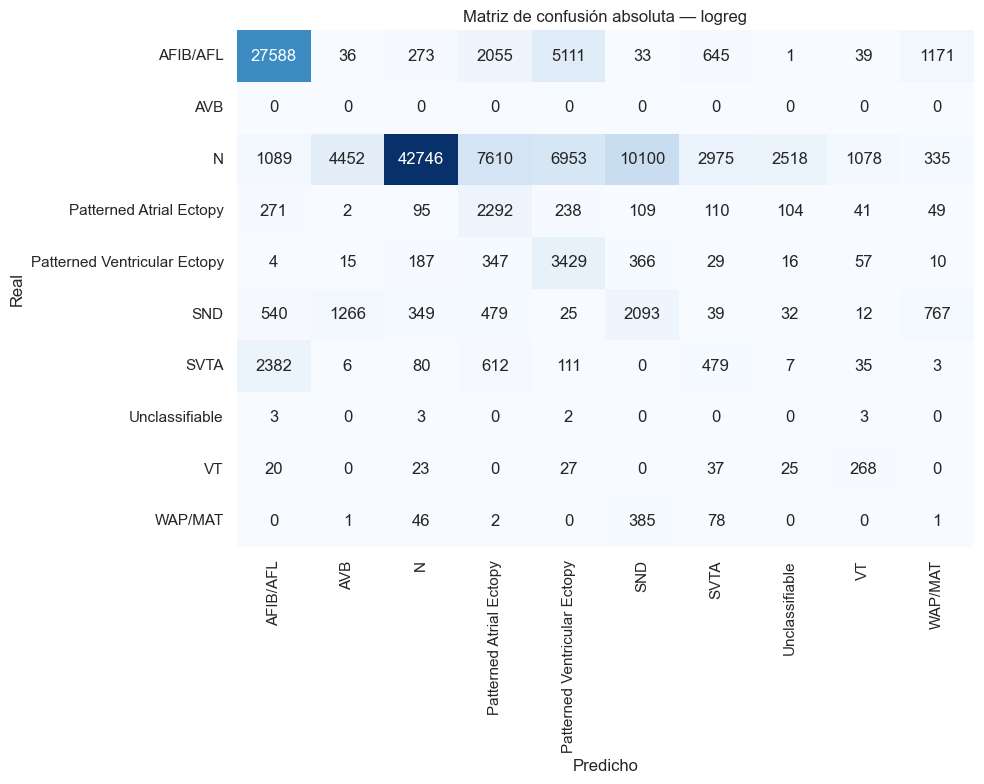


=== random_forest — matriz de confusión absoluta ===
                              AFIB/AFL      N  Patterned Atrial Ectopy  Patterned Ventricular Ectopy  SND  SVTA  Unclassifiable   VT  WAP/MAT  support_true
AFIB/AFL                         34656   2251                        0                             9    0     0               0   36        0         36952
N                                  619  79158                        0                            63    1     1               0   14        0         79856
Patterned Atrial Ectopy           1861   1450                        0                             0    0     0               0    0        0          3311
Patterned Ventricular Ectopy      1430   2929                        0                           100    1     0               0    0        0          4460
SND                                699   4899                        0                             0    4     0               0    0        0          5602
SVTA      

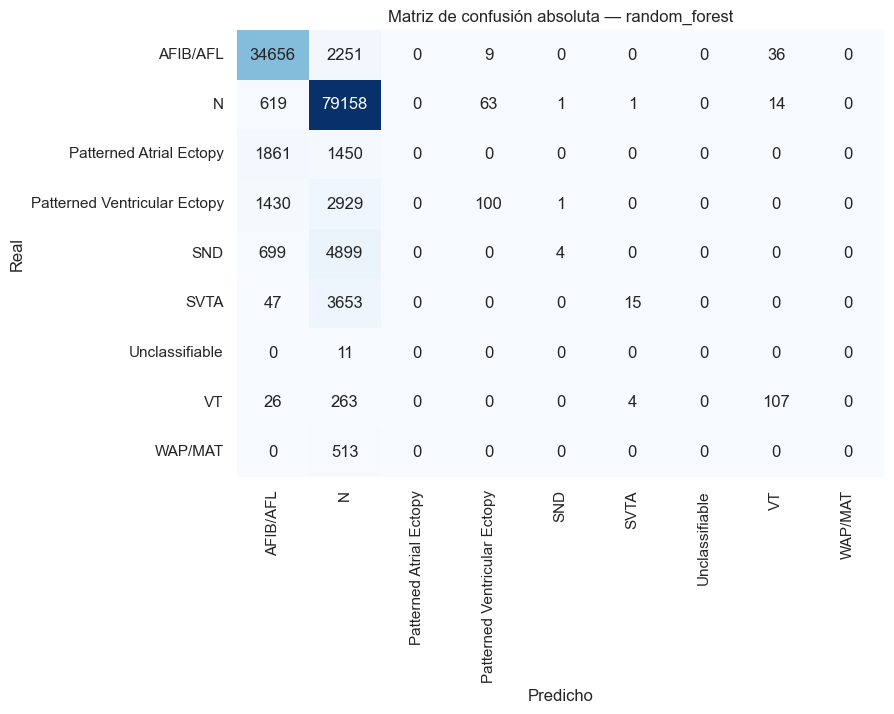

In [15]:
for name, info in results.items():
    cm_df = confusion_matrix_with_totals(y_test, info["y_pred"])
    print(f"=== {name} — matriz de confusión absoluta ===")
    print(cm_df.to_string())

    # Heatmap solo de la submatriz (sin la fila/col de totales).
    inner = cm_df.iloc[:-1, :-1]
    fig, ax = plt.subplots(figsize=(1.0 + 0.9 * inner.shape[1], 1.0 + 0.7 * inner.shape[0]))
    sns.heatmap(
        inner,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(f"Matriz de confusión absoluta — {name}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    plt.tight_layout()
    plt.show()
    print()

## 10. Validación cruzada por grupos (`GroupKFold`)

`safe_n_splits` recorta automáticamente el número de folds al número de `case_id` únicos cuando son menos de los pedidos (`GroupKFold` exige `n_splits <= n_groups`).

Se reporta una métrica por fold y los grupos que cayeron en test de cada fold.

In [16]:
n_splits_eff = safe_n_splits(config.DEFAULT_N_SPLITS, groups)
print(f"n_splits efectivo (recortado por # de grupos): {n_splits_eff}")

fold_metrics = []
for i, (tr, te) in enumerate(make_group_kfold(X, y, groups, n_splits=n_splits_eff)):
    pipe = build_logreg_pipeline(class_weight="balanced")
    pipe.fit(X[tr], y[tr])
    y_pred = pipe.predict(X[te])
    m = compute_macro_metrics(y[te], y_pred)
    m["fold"] = i
    m["test_groups"] = sorted(set(groups[te].tolist()))
    m["n_test"] = int(len(te))
    fold_metrics.append(m)

cv_df = pd.DataFrame(fold_metrics).set_index("fold")
cv_df

n_splits efectivo (recortado por # de grupos): 5


c:\Users\juanc\OneDrive\Documentos\Doctorado\Cursos\Curso machine\vitaldb-arrhythmia-ml\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2924: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,f1_macro,recall_macro,precision_macro,balanced_accuracy,test_groups,n_test
fold,,,,,,
0,0.244247,0.414528,0.257569,0.414528,"[12, 347, 382, 565, 569, 672, 708, 758, 788, 9...",127813
1,0.233029,0.429954,0.251458,0.429954,"[42, 96, 285, 447, 539, 541, 657, 816, 985, 10...",127645
2,0.237311,0.335215,0.255362,0.372461,"[110, 146, 178, 230, 251, 257, 371, 397, 521, ...",127842
3,0.265741,0.387033,0.272771,0.387033,"[13, 103, 114, 158, 166, 208, 244, 345, 387, 4...",127705
4,0.306643,0.550367,0.298373,0.550367,"[19, 98, 174, 212, 232, 253, 337, 365, 388, 45...",127685


In [17]:
numeric_cols = [c for c in cv_df.columns if pd.api.types.is_numeric_dtype(cv_df[c])]
cv_df[numeric_cols].agg(["mean", "std", "min", "max"]).round(3)

,f1_macro,recall_macro,precision_macro,balanced_accuracy,n_test
mean,0.257,0.423,0.267,0.431,127738.000
std,0.030,0.080,0.019,0.070,85.129
min,0.233,0.335,0.251,0.372,127645.000
max,0.307,0.550,0.298,0.550,127842.000


## 11. Lectura del baseline y próximos pasos

Cómo interpretar lo que ves arriba antes de pasar a búsqueda de hiperparámetros:

1. Si en la sección 3 alguna clase aparece en **≤ 1 case_id**, sus métricas en cualquier fold donde ese caso quede en test no serán informativas. Más casos en `03` mitigan esto.
2. Si en la sección 5 hay clases listadas como *missing in train*, su recall será 0 por construcción y `f1_macro` no es comparable contra runs sin ese problema.
3. La matriz de confusión absoluta de la sección 9 muestra dónde están concentrados los errores. Mirar primero las clases con mayor `support_true` (los errores ahí mueven la métrica) y luego las minoritarias.
4. La tabla de la sección 10 expone la variabilidad entre folds. Una media alta con desviación enorme suele indicar que el resultado depende del fold concreto, no del modelo.

Antes de iterar en modelado:

- Asegurar que `03_ecg_loading_and_visualization.ipynb` haya descargado suficientes `case_id`.
- Re-ejecutar `04_windowing_and_feature_engineering.ipynb` para regenerar `features_baseline.parquet` con todos los casos.
- Volver a correr este notebook entero y comparar la sección 10 contra el run anterior.